# SoursopBD Leaf Disease Classifier




In [1]:
!pip install -q scikit-learn seaborn
print("Packages ready.")


Packages ready.


In [2]:
import os, random, time, warnings, zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

SEED = 50
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False



In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}")
    print(f"VRAM   : {props.total_memory / 1e9:.1f} GB")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Step 1 — Configuration

All hyperparameters in one place. Change this cell only when tuning.


In [4]:
CFG = {
    "data_dir"            : "/content/Soursop_V2",
    "img_size"            : 224,
    "batch_size"          : 32,
    "num_classes"         : 6,
    "class_names"         : [
        "Cutting_Caterpillar", "Cutting_Weevil", "Die_Back",
        "Healthy", "White_Fly", "Yellow"
    ],
    "val_split"           : 0.10,
    "test_split"          : 0.10,
    "lr"                  : 1e-3,
    "weight_decay"        : 1e-4,
    "lr_patience"         : 7,
    "lr_factor"           : 0.5,
    "min_lr"              : 1e-6,
    "epochs"              : 100,
    "early_stop_patience" : 15,
    "dropout"             : 0.4,
}

for k, v in CFG.items():
    print(f"  {k:<26} {v}")


  data_dir                   /content/Soursop_V2
  img_size                   224
  batch_size                 32
  num_classes                6
  class_names                ['Cutting_Caterpillar', 'Cutting_Weevil', 'Die_Back', 'Healthy', 'White_Fly', 'Yellow']
  val_split                  0.1
  test_split                 0.1
  lr                         0.001
  weight_decay               0.0001
  lr_patience                7
  lr_factor                  0.5
  min_lr                     1e-06
  epochs                     100
  early_stop_patience        15
  dropout                    0.4


## Step 2 — Dataset Download

Downloads from the Mendeley Data public REST API.
Skips automatically if images are already present.


In [5]:
DATASET_ID = "hjrhrt5hs8"
VERSION    = 2


def stream_download(url, dest, chunk=8192):
    r = requests.get(url, stream=True, timeout=300)
    r.raise_for_status()
    total = 0
    with open(dest, "wb") as f:
        for block in r.iter_content(chunk_size=chunk):
            f.write(block); total += len(block)
    print(f"    {total/1e6:.1f} MB  →  {dest}")


jpg_count = len(list(Path("/content").rglob("*.jpg")))
if jpg_count >= 100:
    print(f"Dataset already present ({jpg_count} images). Skipping.")
else:
    url   = (f"https://data.mendeley.com/api/datasets/"
             f"{DATASET_ID}/files?versionNumber={VERSION}")
    files = requests.get(url, timeout=30).json()
    for meta in files:
        fname  = meta.get("filename") or meta.get("name", "file")
        dl_url = (meta.get("download_url") or
                  f"https://data.mendeley.com/datasets/{DATASET_ID}/{VERSION}"
                  f"/files/{meta['id']}/download")
        print(f"  Downloading: {fname}")
        stream_download(dl_url, f"/content/{fname}")
        if fname.endswith(".zip"):
            with zipfile.ZipFile(f"/content/{fname}") as z:
                z.extractall("/content/")
            os.remove(f"/content/{fname}")
    print("Download complete.")


def find_data_root(base="/content"):
    for root, dirs, _ in os.walk(base):
        hits = sum(1 for c in CFG["class_names"]
                   if any(c.lower() in d.replace(" ", "_").lower() for d in dirs))
        if hits >= 3:
            return root
    return None


data_root = find_data_root()
if data_root:
    CFG["data_dir"] = data_root
    print(f"Data root : {data_root}")
    for d in sorted(os.listdir(data_root)):
        fp = os.path.join(data_root, d)
        if os.path.isdir(fp):
            n = len(list(Path(fp).glob("*.jpg")))
            print(f"  {d:<40}  {n:>4} images")
else:
    print("WARNING: Could not locate class folders. Set CFG['data_dir'] manually.")


  Downloading: BDSoursop_V2.zip
    534.3 MB  →  /content/BDSoursop_V2.zip
Download complete.


## Step 3 — Exploratory Data Analysis




In [6]:
#  Build image manifest
all_paths, all_labels = [], []
folder_to_idx = {}

for folder in sorted(os.listdir(CFG["data_dir"])):
    fp = os.path.join(CFG["data_dir"], folder)
    if not os.path.isdir(fp):
        continue
    fn = folder.replace(" ", "_")
    for idx, cls in enumerate(CFG["class_names"]):
        if cls.lower() in fn.lower():
            folder_to_idx[folder] = idx
            break
    else:
        folder_to_idx[folder] = len(folder_to_idx)

for folder, idx in folder_to_idx.items():
    for img_path in Path(os.path.join(CFG["data_dir"], folder)).glob("*.jpg"):
        all_paths.append(str(img_path))
        all_labels.append(idx)

print(f"Total images : {len(all_paths)}")
print("Folder → class index mapping:")
for f, i in folder_to_idx.items():
    label = CFG["class_names"][i] if i < len(CFG["class_names"]) else "unknown"
    print(f"  {f:<40}  {i}  ({label})")

for folder, idx in folder_to_idx.items():
    for img_file in Path(os.path.join(CFG["data_dir"], folder)).glob("*.jpg"):
        all_paths.append(str(img_file))
        all_labels.append(idx)





Total images : 3838
Folder → class index mapping:
  CuttingCaterpillars                       0  (Cutting_Caterpillar)
  CuttingWeevils                            1  (Cutting_Weevil)
  DieBack                                   2  (Die_Back)
  Healthy                                   3  (Healthy)
  WhiteFly                                  4  (White_Fly)
  Yellow                                    5  (Yellow)


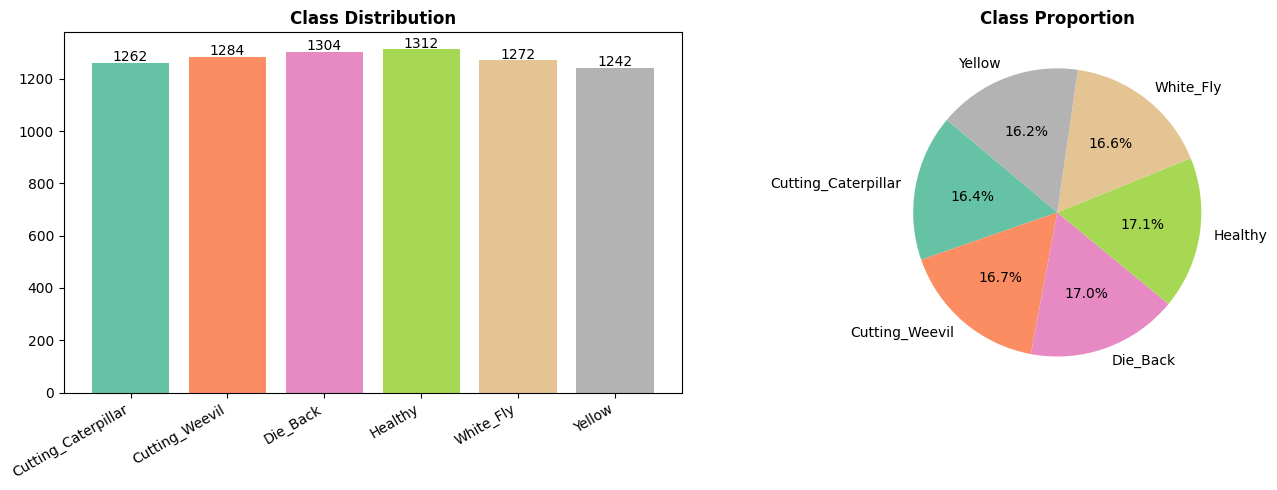

Imbalance ratio : 1.1×
  Cutting_Caterpillar        1262  (16.4%)
  Cutting_Weevil             1284  (16.7%)
  Die_Back                   1304  (17.0%)
  Healthy                    1312  (17.1%)
  White_Fly                  1272  (16.6%)
  Yellow                     1242  (16.2%)


In [7]:
#  Class distribution
counts       = Counter(all_labels)
class_counts = [counts.get(i, 0) for i in range(CFG["num_classes"])]
colours      = plt.cm.Set2(np.linspace(0, 1, CFG["num_classes"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(CFG["class_names"], class_counts, color=colours)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_xticklabels(CFG["class_names"], rotation=30, ha="right")
for bar, n in zip(bars, class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(n), ha="center")
axes[1].pie(class_counts, labels=CFG["class_names"],
            autopct="%1.1f%%", colors=colours, startangle=140)
axes[1].set_title("Class Proportion", fontweight="bold")
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

imbalance = max(class_counts) / min(c for c in class_counts if c > 0)
print(f"Imbalance ratio : {imbalance:.1f}×")
for cls, n in zip(CFG["class_names"], class_counts):
    print(f"  {cls:<25}  {n:>4}  ({n/len(all_paths)*100:.1f}%)")


Checking for exact duplicate images (MD5 hash)...
  Images in duplicate groups : 7676
  Redundant copies           : 4399
  → 4399 images are exact copies of another image in the dataset.
  → Deduplication applied before splitting to prevent data leakage.

After deduplication:
  Original : 7676 images
  Unique   : 3277 images
  Removed  : 4399 duplicates


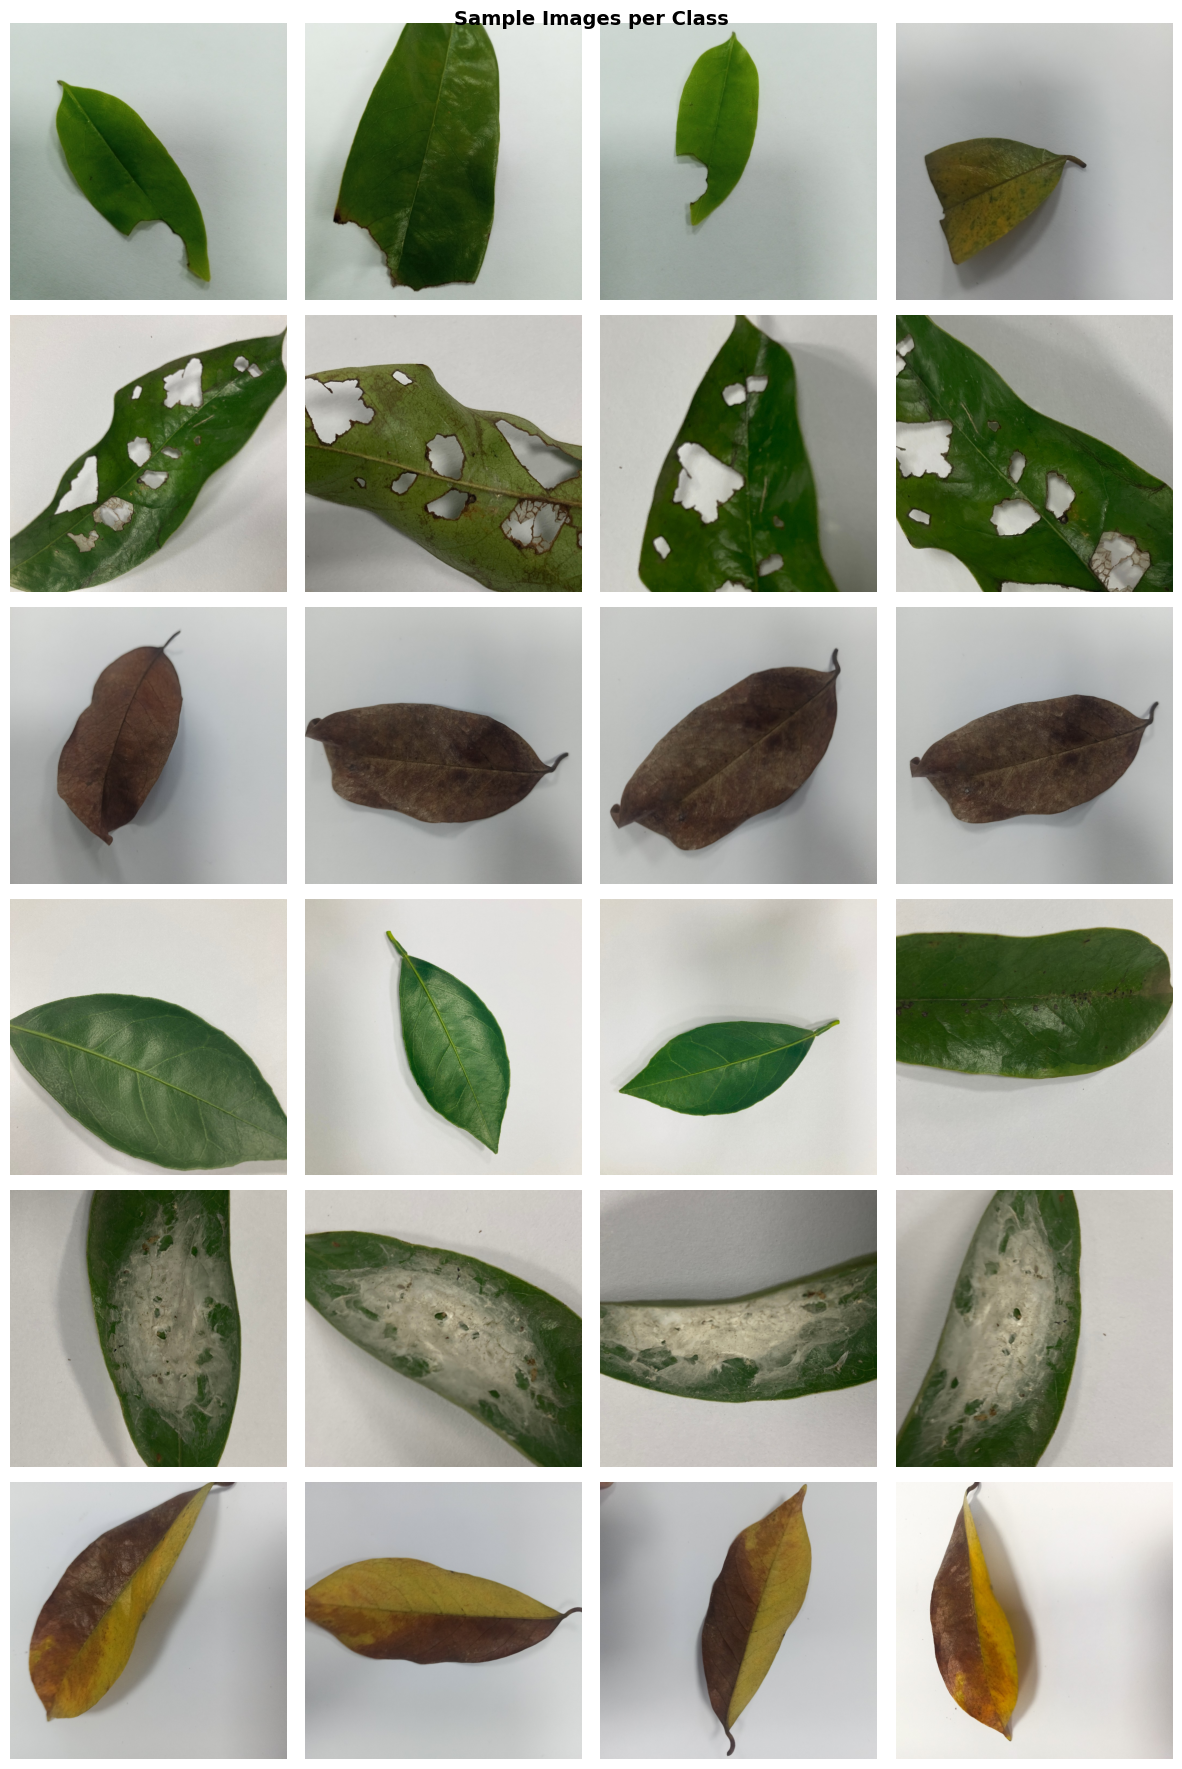

In [8]:
from collections import defaultdict
import hashlib

#  Duplicate check
print("\nChecking for exact duplicate images (MD5 hash)...")
hash_to_paths = defaultdict(list)
for path in all_paths:
    with open(path, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    hash_to_paths[h].append(path)

dup_groups  = {h: v for h, v in hash_to_paths.items() if len(v) > 1}
n_dup_files = sum(len(v) for v in dup_groups.values())
n_dup_extra = sum(len(v) - 1 for v in dup_groups.values())

print(f"  Images in duplicate groups : {n_dup_files}")
print(f"  Redundant copies           : {n_dup_extra}")

if n_dup_extra > 0:
    print(f"  → {n_dup_extra} images are exact copies of another image in the dataset.")
    print("  → Deduplication applied before splitting to prevent data leakage.")

# ── Deduplicate: keep only one image per hash ─────────────────────────────────
unique_paths, unique_labels = [], []
seen_hashes = set()
for path, label in zip(all_paths, all_labels):
    with open(path, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    if h not in seen_hashes:
        seen_hashes.add(h)
        unique_paths.append(path)
        unique_labels.append(label)

print(f"\nAfter deduplication:")
print(f"  Original : {len(all_paths)} images")
print(f"  Unique   : {len(unique_paths)} images")
print(f"  Removed  : {len(all_paths) - len(unique_paths)} duplicates")

# ── Sample images ─────────────────────────────────────────────────────────────
n_samples = 4
fig, axes = plt.subplots(CFG["num_classes"], n_samples,
                          figsize=(n_samples*3, CFG["num_classes"]*3))
for cls_idx in range(CFG["num_classes"]):
    cls_paths = [p for p, l in zip(unique_paths, unique_labels) if l == cls_idx]
    samples   = random.sample(cls_paths, min(n_samples, len(cls_paths)))
    for j, img_path in enumerate(samples):
        from PIL import Image
        img = Image.open(img_path).convert("RGB")
        axes[cls_idx, j].imshow(img)
        axes[cls_idx, j].axis("off")
        if j == 0:
            axes[cls_idx, j].set_ylabel(
                CFG["class_names"][cls_idx], fontsize=10,
                rotation=0, ha="right", va="center",
                labelpad=90, fontweight="bold"
            )
plt.suptitle("Sample Images per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/sample_images.png", dpi=80, bbox_inches="tight")
plt.show()

# Step 4 — Dataset Class & Augmentation Pipeline





In [9]:
class LeafDiseaseDataset(Dataset):
    """
    Custom Dataset for SoursopBD leaf disease images.
    Applies augmented transforms for train split,
    deterministic transforms for val/test.
    """
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, image_paths, labels, img_size=224, split="train"):
        self.paths     = list(image_paths)
        self.labels    = list(labels)
        self.transform = self._build_transform(img_size, split)

    def _build_transform(self, size, split):
        if split == "train":
            return T.Compose([

                T.Resize((size + 24, size + 24)),
                T.RandomResizedCrop(size, scale=(0.75, 1.0)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.3),
                T.RandomRotation(degrees=30),
                T.ColorJitter(
                    brightness=0.3,
                    contrast=0.3,
                    saturation=0.10,
                    hue=0.05,
                ),
                T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
                T.ToTensor(),
                T.Normalize(mean=self.MEAN, std=self.STD),
                T.RandomErasing(p=0.20, scale=(0.02, 0.10)),
            ])
        else:
            return T.Compose([
                T.Resize((size, size)),
                T.ToTensor(),
                T.Normalize(mean=self.MEAN, std=self.STD),
            ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]
        return self.transform(img), label


# Quick sanity check
_ds   = LeafDiseaseDataset(all_paths[:4], all_labels[:4], split="train")
_x, _y = _ds[0]
print(f"Output tensor shape : {_x.shape}  (C × H × W)")
print(f"Dtype               : {_x.dtype}")
print(f"Value range         : [{_x.min():.2f}, {_x.max():.2f}]  (normalised)")
print(f"Label               : {_y}  →  {CFG['class_names'][_y]}")


Output tensor shape : torch.Size([3, 224, 224])  (C × H × W)
Dtype               : torch.float32
Value range         : [-1.60, 2.17]  (normalised)
Label               : 0  →  Cutting_Caterpillar


Split sizes:
  Train : 6140
  Val   :  768
  Test  :  768
  Train per-class counts: [1010, 1026, 1042, 1050, 1018, 994]
  Val per-class counts: [126, 129, 131, 131, 127, 124]
  Test per-class counts: [126, 129, 131, 131, 127, 124]

Batches per training epoch : 192


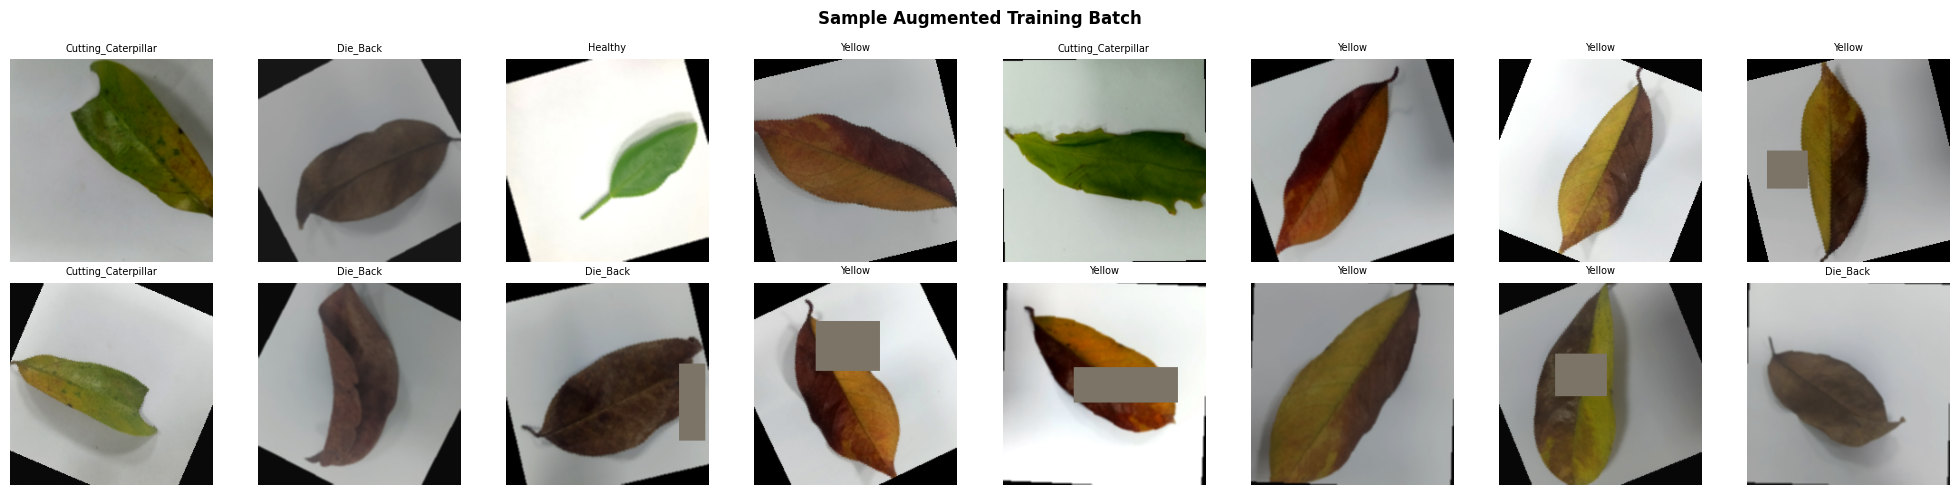

In [10]:
if "num_workers" not in CFG:
    CFG["num_workers"] = 2

# ── Stratified train / val / test split ───────────────────────
# WHY stratified: with imbalanced classes, random split could put
# zero samples of a rare class in the validation set.

paths_arr  = np.array(all_paths)
labels_arr = np.array(all_labels)

# Hold out test set first
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    paths_arr, labels_arr,
    test_size=CFG["test_split"],
    stratify=labels_arr,
    random_state=SEED,
)

# Split train / val from remaining
val_frac = CFG["val_split"] / (1.0 - CFG["test_split"])
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=val_frac,
    stratify=train_val_labels,
    random_state=SEED,
)

print("Split sizes:")
print(f"  Train : {len(train_paths):>4}")
print(f"  Val   : {len(val_paths):>4}")
print(f"  Test  : {len(test_paths):>4}")

for name, lbls in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    dist = [sum(1 for l in lbls if l == i) for i in range(CFG["num_classes"])]
    print(f"  {name} per-class counts: {dist}")


# ── WeightedRandomSampler ──────────────────────────────────────
# WHY: ensures each training batch sees roughly balanced classes
# even when the dataset is not balanced.
train_cc  = Counter(train_labels)
sample_wt = [1.0 / train_cc[l] for l in train_labels]
sampler   = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_wt),
    num_samples=len(train_labels),
    replacement=True,
)


# ── Build datasets ─────────────────────────────────────────────
train_ds = LeafDiseaseDataset(train_paths, train_labels, CFG["img_size"], "train")
val_ds   = LeafDiseaseDataset(val_paths,   val_labels,   CFG["img_size"], "val")
test_ds  = LeafDiseaseDataset(test_paths,  test_labels,  CFG["img_size"], "test")


# ── Build DataLoaders ──────────────────────────────────────────
train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    sampler=sampler,           # replaces shuffle=True
    num_workers=CFG["num_workers"],
    pin_memory=True,           # faster CPU → GPU transfer
    persistent_workers=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    persistent_workers=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
)

print(f"\nBatches per training epoch : {len(train_loader)}")


# ── Visualise one augmented batch ──────────────────────────────
MEAN_T = torch.tensor(LeafDiseaseDataset.MEAN).view(3, 1, 1)
STD_T  = torch.tensor(LeafDiseaseDataset.STD).view(3, 1, 1)

def denorm(t):
    return (t * STD_T + MEAN_T).clamp(0, 1)

imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs):
        ax.axis("off")
        continue
    img = denorm(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CFG["class_names"][lbls[i]], fontsize=7)
    ax.axis("off")
plt.suptitle("Sample Augmented Training Batch", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/augmented_batch.png", dpi=80, bbox_inches="tight")
plt.show()

## Step 5 — Model Architecture


In [11]:
# ── Residual Block ────────────────────────────────────────────
class ResidualBlock(nn.Module):
    """
    Two 3×3 conv layers with a skip connection.

    The skip connection lets gradients bypass the conv layers entirely,
    solving the vanishing gradient problem in deep networks trained
    from random initialisation.

    When in_ch != out_ch or stride != 1, a 1×1 conv realigns
    the skip connection's dimensions.
    """

    def __init__(self, in_ch: int, out_ch: int, stride: int = 1):
        super().__init__()

        # ── Main path ──────────────────────────────────────────
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # ── Skip (identity or projection) ──────────────────────
        self.skip = None
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.skip is not None:
            identity = self.skip(x)

        # Add identity BEFORE the final activation
        return self.relu(out + identity)


# ── Full CNN ───────────────────────────────────────────────────
class SoursopCNN(nn.Module):
    """
    Custom lightweight ResNet-style CNN.
    No pretrained weights. Designed for 224×224 input, 6 output classes.
    """

    def __init__(self, num_classes: int = 6, dropout: float = 0.4):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )   # → (B, 64, 56, 56)

        self.layer1 = self._make_layer(64,  64,  n=2, stride=1)  # → (B,  64, 56, 56)
        self.layer2 = self._make_layer(64,  128, n=2, stride=2)  # → (B, 128, 28, 28)
        self.layer3 = self._make_layer(128, 256, n=2, stride=2)  # → (B, 256, 14, 14)
        self.layer4 = self._make_layer(256, 512, n=2, stride=2)  # → (B, 512,  7,  7)

        # Global Average Pooling — replaces Flatten + large FC layer
        # WHY: zero parameters; collapses spatial dims regardless of input size;
        # built-in translational invariance (disease can be anywhere on leaf)
        self.gap = nn.AdaptiveAvgPool2d(1)   # → (B, 512, 1, 1)

        self.dropout    = nn.Dropout(p=dropout)
        self.classifier = nn.Linear(512, num_classes)

        self._init_weights()

    @staticmethod
    def _make_layer(in_ch, out_ch, n, stride):
        """First block handles stride/channel change; rest maintain dimensions."""
        layers = [ResidualBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, n):
            layers.append(ResidualBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def _init_weights(self):
        """
        Kaiming (He) normal for Conv layers.
        WHY: derived under the assumption of ReLU nonlinearity.
        Keeps activation variance stable through many layers,
        preventing exploding/vanishing signal at the start of training.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).flatten(1)   # (B, 512)
        x = self.dropout(x)
        return self.classifier(x)    # raw logits — softmax handled inside loss


# ── Instantiate ────────────────────────────────────────────────
model = SoursopCNN(
    num_classes=CFG["num_classes"],
    dropout=CFG["dropout"],
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")

# Shape verification
_x = torch.randn(2, 3, CFG["img_size"], CFG["img_size"]).to(device)
_y = model(_x)
print(f"Input  shape : {list(_x.shape)}")
print(f"Output shape : {list(_y.shape)}   (batch × 6 classes)")


Total parameters     : 11,179,590
Trainable parameters : 11,179,590
Input  shape : [2, 3, 224, 224]
Output shape : [2, 6]   (batch × 6 classes)


## Step 6 — Training Setup

In [12]:
# ── Weighted cross-entropy ─────────────────────────────────────
train_counts  = [sum(1 for l in train_labels if l == i)
                 for i in range(CFG["num_classes"])]
total_train   = len(train_labels)
loss_weights  = [
    total_train / (CFG["num_classes"] * c) if c > 0 else 1.0
    for c in train_counts
]
loss_weights  = torch.tensor(loss_weights, dtype=torch.float32).to(device)
criterion     = nn.CrossEntropyLoss(weight=loss_weights)

print("Class loss weights (higher weight → rarer class → penalised more):")
for cls, cnt, w in zip(CFG["class_names"], train_counts, loss_weights.cpu()):
    print(f"  {cls:<25}  n={cnt:>4}   weight={w:.3f}")


# ── Optimiser ──────────────────────────────────────────────────
optimizer = optim.Adam(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)


# ── LR scheduler ───────────────────────────────────────────────
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CFG["lr_factor"],
    patience=CFG["lr_patience"],
    min_lr=CFG["min_lr"],
)


# ── Early stopping ──────────────────────────────────────────────
class EarlyStopping:
    """
    Tracks validation loss. Saves the best checkpoint.
    Returns True (stop training) when patience is exceeded.
    """
    def __init__(self, patience=15, path="/content/best_model.pth"):
        self.patience   = patience
        self.path       = path
        self.best_loss  = float("inf")
        self.best_epoch = 0
        self.counter    = 0

    def step(self, val_loss, model, epoch):
        if val_loss < self.best_loss - 1e-4:    # improvement threshold
            self.best_loss  = val_loss
            self.best_epoch = epoch
            self.counter    = 0
            torch.save(model.state_dict(), self.path)
            return False
        self.counter += 1
        if self.counter >= self.patience:
            print(f"  Early stopping at epoch {epoch}. "
                  f"Best epoch: {self.best_epoch}  val_loss={self.best_loss:.4f}")
            return True
        return False


early_stopper = EarlyStopping(
    patience=CFG["early_stop_patience"],
    path="/content/best_model.pth",
)

print("\nSetup complete.")
print(f"  Criterion : CrossEntropyLoss (weighted)")
print(f"  Optimiser : Adam  lr={CFG['lr']}  wd={CFG['weight_decay']}")
print(f"  Scheduler : ReduceLROnPlateau  patience={CFG['lr_patience']}")
print(f"  EarlyStop : patience={CFG['early_stop_patience']}")

Class loss weights (higher weight → rarer class → penalised more):
  Cutting_Caterpillar        n=1010   weight=1.013
  Cutting_Weevil             n=1026   weight=0.997
  Die_Back                   n=1042   weight=0.982
  Healthy                    n=1050   weight=0.975
  White_Fly                  n=1018   weight=1.005
  Yellow                     n= 994   weight=1.030

Setup complete.
  Criterion : CrossEntropyLoss (weighted)
  Optimiser : Adam  lr=0.001  wd=0.0001
  Scheduler : ReduceLROnPlateau  patience=7
  EarlyStop : patience=15


## Step 7 — Training Loop


In [13]:
def run_epoch(model, loader, criterion, optimizer=None, phase="train"):
    """
    One epoch of training or evaluation.
    phase='train' : computes + applies gradients.
    phase='val'   : torch.no_grad(), read-only.
    """
    is_train = (phase == "train")
    model.train() if is_train else model.eval()

    total_loss = correct = total = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()

                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion,
                optimizer, scheduler, early_stopper, epochs):
    """Full training run. Returns history dict for plotting."""

    history = {k: [] for k in
               ["train_loss", "val_loss", "train_acc", "val_acc", "lr"]}

    header = (f"{'Epoch':>6}  {'TrLoss':>8}  {'VaLoss':>8}  "
              f"{'TrAcc':>7}  {'VaAcc':>7}  {'LR':>9}  Time")
    print(header)
    print("-" * len(header))

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_epoch(model, train_loader, criterion,
                                    optimizer, "train")
        va_loss, va_acc = run_epoch(model, val_loader,   criterion,
                                    phase="val")

        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(va_loss)

        for key, val in zip(
            ["train_loss","val_loss","train_acc","val_acc","lr"],
            [tr_loss, va_loss, tr_acc, va_acc, current_lr]
        ):
            history[key].append(val)

        elapsed = time.time() - t0
        print(f"{epoch:>6}  {tr_loss:>8.4f}  {va_loss:>8.4f}  "
              f"{tr_acc:>7.4f}  {va_acc:>7.4f}  "
              f"{current_lr:>9.2e}  {elapsed:.1f}s")

        if early_stopper.step(va_loss, model, epoch):
            break

    print("\nRestoring best weights ...")
    model.load_state_dict(torch.load("/content/best_model.pth"))
    print(f"Best epoch: {early_stopper.best_epoch}  |  "
          f"Best val loss: {early_stopper.best_loss:.4f}")

    return history


print("Training functions defined.")


Training functions defined.


In [14]:
print("Starting training ...")
print(f"  Parameters  : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Train imgs  : {len(train_ds)}")
print(f"  Val imgs    : {len(val_ds)}")
print(f"  Max epochs  : {CFG['epochs']}")
print(f"  Batch size  : {CFG['batch_size']}")
print()

history = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    optimizer    = optimizer,
    scheduler    = scheduler,
    early_stopper= early_stopper,
    epochs       = CFG["epochs"],
)


Starting training ...
  Parameters  : 11,179,590
  Train imgs  : 6140
  Val imgs    : 768
  Max epochs  : 100
  Batch size  : 32

 Epoch    TrLoss    VaLoss    TrAcc    VaAcc         LR  Time
-------------------------------------------------------------
     1    0.7965    0.6578   0.7482   0.7995   1.00e-03  145.8s
     2    0.4051    0.1564   0.8746   0.9375   1.00e-03  140.8s
     3    0.2836    0.3551   0.9158   0.9154   1.00e-03  140.0s
     4    0.2097    0.0506   0.9355   0.9844   1.00e-03  139.9s
     5    0.1869    0.0238   0.9489   0.9961   1.00e-03  141.3s
     6    0.1409    0.0296   0.9557   0.9909   1.00e-03  139.5s
     7    0.1330    0.0126   0.9616   0.9974   1.00e-03  141.4s
     8    0.1137    0.8726   0.9664   0.8060   1.00e-03  140.4s
     9    0.1087    0.0046   0.9676   0.9987   1.00e-03  140.8s
    10    0.0933    0.0953   0.9707   0.9635   1.00e-03  138.0s
    11    0.0835    0.0200   0.9735   0.9948   1.00e-03  138.8s
    12    0.0680    1.1180   0.9796   0.77

## Step 8 — Training Curves


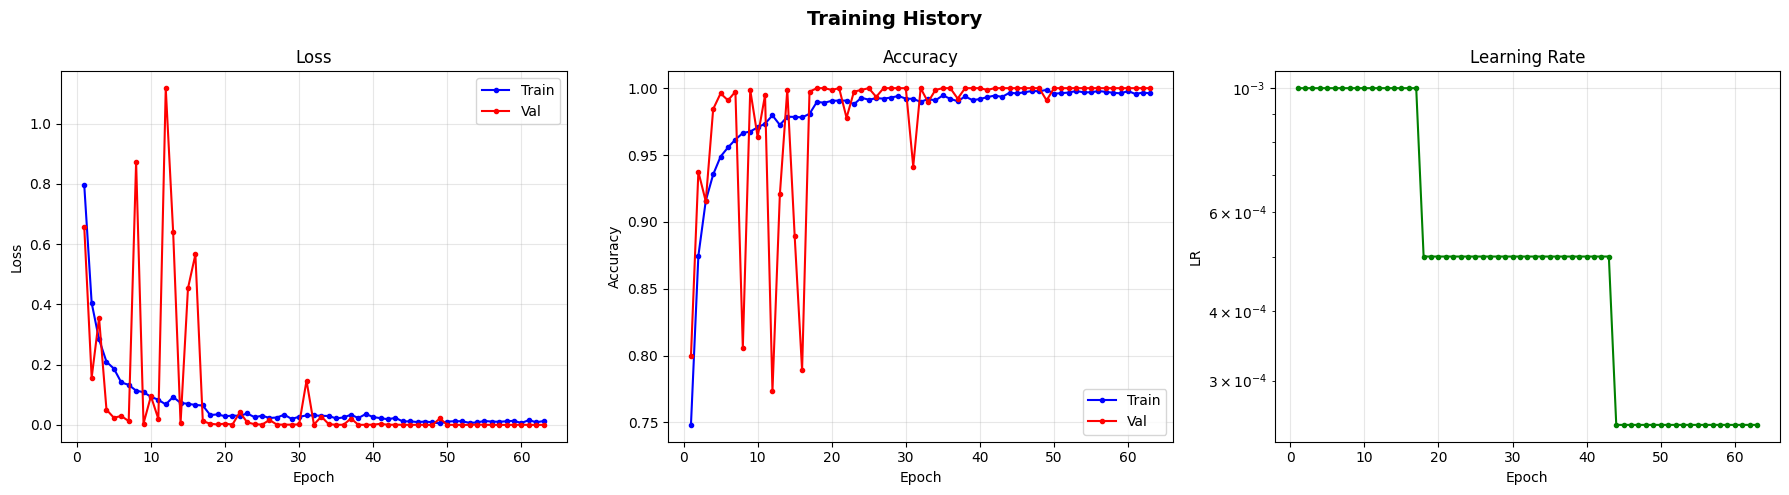

Best epoch  : 62
Train loss  : 0.0089
Val loss    : 0.0001
Gap (va-tr) : -0.0088
→ Healthy gap.


In [15]:
def plot_history(history):
    epochs_ran = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training History", fontsize=14, fontweight="bold")

    # Loss
    axes[0].plot(epochs_ran, history["train_loss"], "b-o", ms=3, label="Train")
    axes[0].plot(epochs_ran, history["val_loss"],   "r-o", ms=3, label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs_ran, history["train_acc"], "b-o", ms=3, label="Train")
    axes[1].plot(epochs_ran, history["val_acc"],   "r-o", ms=3, label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # LR
    axes[2].plot(epochs_ran, history["lr"], "g-o", ms=3)
    axes[2].set_title("Learning Rate")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
    axes[2].set_yscale("log"); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/training_curves.png", dpi=100, bbox_inches="tight")
    plt.show()

    best_ep    = int(np.argmin(history["val_loss"]))
    best_tr    = history["train_loss"][best_ep]
    best_va    = history["val_loss"][best_ep]
    gap        = best_va - best_tr

    print(f"Best epoch  : {best_ep + 1}")
    print(f"Train loss  : {best_tr:.4f}")
    print(f"Val loss    : {best_va:.4f}")
    print(f"Gap (va-tr) : {gap:.4f}")

    if gap > 0.3:
        print("→ Moderate overfitting. Consider stronger augmentation or higher dropout.")
    elif gap < -0.05:
        print("→ Val loss slightly below train loss — normal with dropout + BN on train.")
    else:
        print("→ Healthy gap.")


plot_history(history)


## Step 9 — Test Set Evaluation


In [16]:
def evaluate(model, loader, class_names, split_name="Test"):
    """Full evaluation on a DataLoader. Returns preds and ground truth."""
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for images, labels in loader:
            preds = model(images.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(labels.numpy())

    y_pred = np.array(all_preds)
    y_true = np.array(all_true)

    acc      = (y_pred == y_true).mean()
    macro_f1 = f1_score(y_true, y_pred, average="macro",   zero_division=0)
    macro_p  = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_r  = recall_score(y_true, y_pred, average="macro",  zero_division=0)

    sep = "=" * 55
    print(f"\n{sep}")
    print(f"  {split_name} Set Results")
    print(sep)
    print(f"  Accuracy           : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  Macro Precision    : {macro_p:.4f}")
    print(f"  Macro Recall       : {macro_r:.4f}")
    print(f"  Macro F1 (primary) : {macro_f1:.4f}")
    print(sep)

    print("\nPer-class report:")
    print(classification_report(y_true, y_pred,
                                  target_names=class_names,
                                  zero_division=0))

    return y_pred, y_true, macro_f1


test_preds, test_true, test_f1 = evaluate(
    model, test_loader, CFG["class_names"], "Test"
)
val_preds, val_true, val_f1 = evaluate(
    model, val_loader, CFG["class_names"], "Validation"
)



  Test Set Results
  Accuracy           : 1.0000  (100.0%)
  Macro Precision    : 1.0000
  Macro Recall       : 1.0000
  Macro F1 (primary) : 1.0000

Per-class report:
                     precision    recall  f1-score   support

Cutting_Caterpillar       1.00      1.00      1.00       126
     Cutting_Weevil       1.00      1.00      1.00       129
           Die_Back       1.00      1.00      1.00       131
            Healthy       1.00      1.00      1.00       131
          White_Fly       1.00      1.00      1.00       127
             Yellow       1.00      1.00      1.00       124

           accuracy                           1.00       768
          macro avg       1.00      1.00      1.00       768
       weighted avg       1.00      1.00      1.00       768


  Validation Set Results
  Accuracy           : 1.0000  (100.0%)
  Macro Precision    : 1.0000
  Macro Recall       : 1.0000
  Macro F1 (primary) : 1.0000

Per-class report:
                     precision    recall  f

**Confusion matrix**

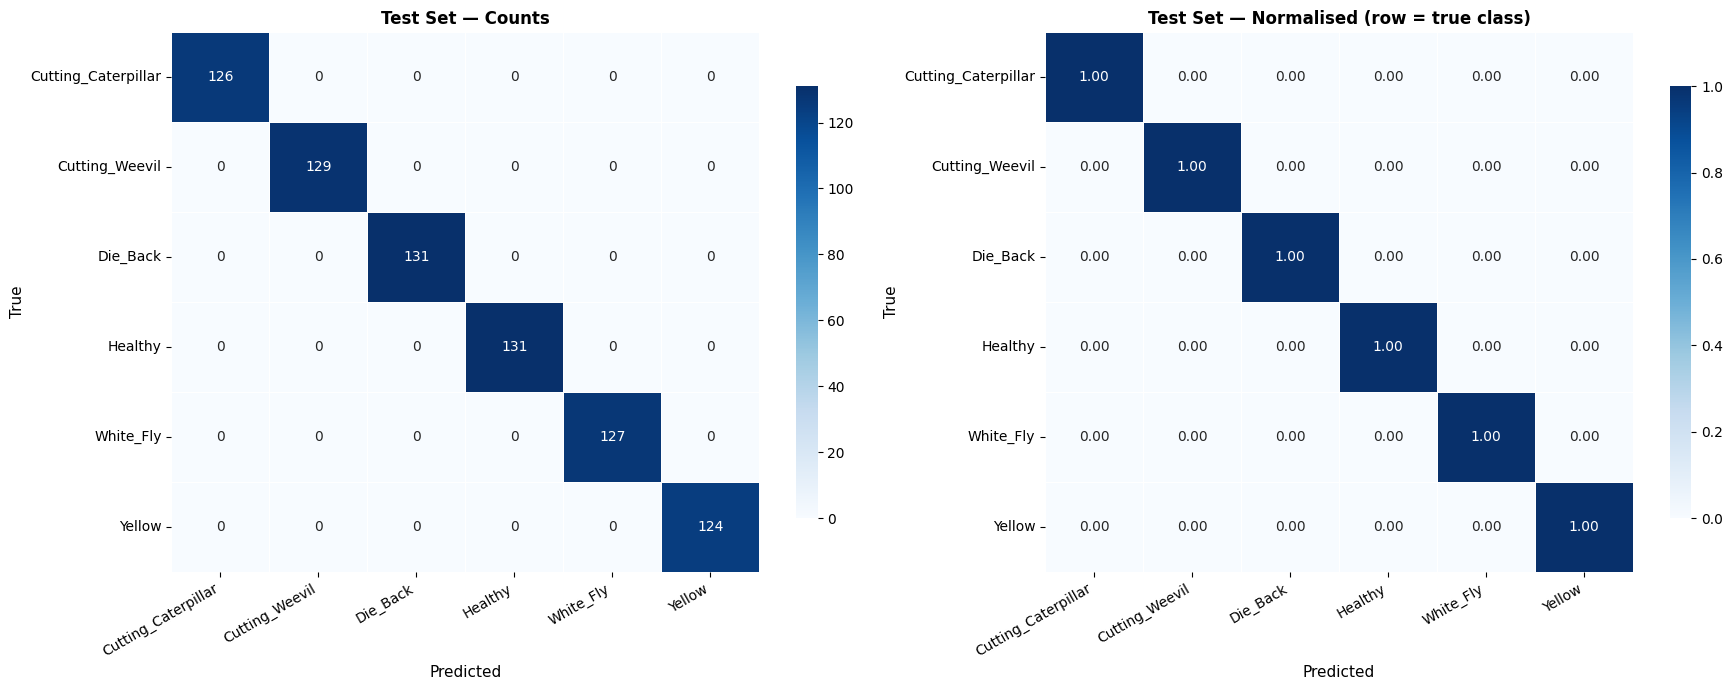

Most confused pair : True=Cutting_Caterpillar  →  Predicted=Cutting_Caterpillar  (126 mistakes)
Interpretation: these classes likely share visual features (e.g., colour or texture). A specialist might also find them ambiguous.


In [17]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, data, fmt, t in [
        (axes[0], cm,      "d",    f"{title} — Counts"),
        (axes[1], cm_norm, ".2f",  f"{title} — Normalised (row = true class)"),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt,
                    xticklabels=class_names,
                    yticklabels=class_names,
                    cmap="Blues", ax=ax, linewidths=0.5,
                    cbar_kws={"shrink": 0.8})
        ax.set_title(t, fontsize=12, fontweight="bold")
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True",      fontsize=11)
        ax.set_xticklabels(class_names, rotation=30, ha="right")
        ax.set_yticklabels(class_names, rotation=0)

    plt.tight_layout()
    plt.savefig("/content/confusion_matrix.png", dpi=100, bbox_inches="tight")
    plt.show()

    # Most confused pair
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    r, c = np.unravel_index(cm_no_diag.argmax(), cm.shape)
    print(f"Most confused pair : True={class_names[r]}  →  "
          f"Predicted={class_names[c]}  ({cm[r,c]} mistakes)")
    print("Interpretation: these classes likely share visual features "
          "(e.g., colour or texture). A specialist might also find them "
          "ambiguous.")


plot_confusion_matrix(test_true, test_preds,
                       CFG["class_names"], "Test Set")
